<a href="https://colab.research.google.com/github/Sigurd-RW/lis4693/blob/main/final%20project/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install gensim
!pip install pyldavis
!pip install nltk

In [22]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

In [24]:
import requests
import io

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2020/2020-09-29/taylor_swift_lyrics.csv"

response = requests.get(url)
response.raise_for_status()

text = response.text

In [25]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(io.StringIO(text), on_bad_lines='skip')
print(df.head(10))

         Artist           Album                       Title   \
0  Taylor Swift   Taylor Swift                    Tim McGraw   
1  Taylor Swift   Taylor Swift               Picture to Burn   
2  Taylor Swift   Taylor Swift       Teardrops on my Guitar    
3  Taylor Swift   Taylor Swift        A Place in This World    
4  Taylor Swift   Taylor Swift                  Cold As You    
5  Taylor Swift   Taylor Swift                   The Outside   
6  Taylor Swift   Taylor Swift   Tied Together With A Smile    
7  Taylor Swift   Taylor Swift               Stay Beautiful    
8  Taylor Swift   Taylor Swift             Should’ve Said No   
9  Taylor Swift   Taylor Swift                  Mary’s Song    

                                              Lyrics  
0  He said the way my blue eyes shinx\nPut those ...  
1  State the obvious, I didn't get my perfect fan...  
2  Drew looks at me,\nI fake a smile so he won't ...  
3  I don't know what I want, so don't ask me\n'Ca...  
4  You have a way of

In [26]:
df_text = df[["Lyrics"]].copy()
df_text.head(10)

,Lyrics
0,He said the way my blue eyes shinx\nPut those ...
1,"State the obvious, I didn't get my perfect fan..."
2,"Drew looks at me,\nI fake a smile so he won't ..."
3,"I don't know what I want, so don't ask me\n'Ca..."
4,You have a way of coming easily to me\nAnd whe...
5,I didn't know what I would find\nWhen I went l...
6,Seems the only one who doesn't see your beauty...
7,Cory's eyes are like a jungle\nHe smiles; it's...
8,It's strange to think the songs we used to sin...
9,"She said\n""I was seven, and you were nine\nI l..."


In [27]:
docs = df.Lyrics.tolist()
print(docs[0])

He said the way my blue eyes shinx
Put those Georgia stars to shame that night
I said: "That's a lie."
Just a boy in a Chevy truck
That had a tendency of gettin' stuck
On back roads at night
And I was right there beside him all summer long
And then the time we woke up to find that summer had gone
But when you think "Tim McGraw"
I hope you think my favorite song
The one we danced to all night long
The moon like a spotlight on the lake
When you think happiness
I hope you think "that little black dress"
Think of my head on your chest
And my old faded blue jeans
When you think Tim McGraw
I hope you think of me
September saw a month of tears
And thankin' God that you weren't here
To see me like that
But in a box beneath my bed
Is a letter that you never read
From three summers back
It's hard not to find it all a little bitter sweet
And lookin' back on all of that, it's nice to believe
But when you think "Tim McGraw"
I hope you think my favorite song
The one we danced to all night long
The m

In [28]:
stop_words = stopwords.words('english')

In [29]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words

In [30]:

## Adding custom stopwords

custom_stopwords = ['know', 'think', 'dont', 'im', 'like', 'youre',
                    'oh', 'never', 'gonna', 'one', 'want',
                    'see', 'back', 'yet', 'say',
                    'ill', 'cause', 'ha', 'would', 'go', 'got',
                    'ever', 'id', 'could', 'cant', 'come', 'wanna', 'ooh', 'ohoh',
                    'mean', 'right', 'yeah', 'thats', 'let', 'shes',
                    'last', 'take', 'said', 'get', 'call',
                    'knows', 'youll', 'ive', 'shouldve',
                    'still', 'ah', 'tell', 'time']

stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['know', 'think', 'dont', 'im', 'like', 'youre', 'oh', 'never', 'gonna', 'one', 'want', 'see', 'back', 'yet', 'say', 'ill', 'cause', 'ha', 'would', 'go', 'got', 'ever', 'id', 'could', 'cant', 'come', 'wanna', 'ooh', 'ohoh', 'mean', 'right', 'yeah', 'thats', 'let', 'shes', 'last', 'take', 'said', 'get', 'call', 'knows', 'youll', 'ive', 'shouldve', 'still', 'ah', 'tell', 'time']


In [31]:
cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
He said the way my blue eyes shinx
Put those Georgia stars to shame that night
I said: "That's a lie."
Just a boy in a Chevy truck
That had a tendency of gettin' stuck
On back roads at night
And I was right there beside him all summer long
And then the time we woke up to find that summer had gone
But when you think "Tim McGraw"
I hope you think my favorite song
The one we danced to all night long
The moon like a spotlight on the lake
When you think happiness
I hope you think "that little black dress"
Think of my head on your chest
And my old faded blue jeans
When you think Tim McGraw
I hope you think of me
September saw a month of tears
And thankin' God that you weren't here
To see me like that
But in a box beneath my bed
Is a letter that you never read
From three summers back
It's hard not to find it all a little bitter sweet
And lookin' back on all of that, it's nice 

In [32]:
cleaned_docs = [clean_doc(doc) for doc in docs]

In [33]:
id2word = corpora.Dictionary(cleaned_docs)

In [34]:
lda_10 = LdaModel(corpus=corpus, id2word=id2word, num_topics=10)
lda_20 = LdaModel(corpus=corpus, id2word=id2word, num_topics=20)

In [35]:
print("\n--- Top words for all topics in lda_10 model ---")
for i in range(lda_10.num_topics):
    terms = lda_10.get_topic_terms(i, 5)
    print(f"Topic {i}:")
    for num, prob in terms:
        print(f"  {id2word[num]} (probability: {prob:.4f})")
    print()


--- Top words for all topics in lda_10 model ---
Topic 0:
  love (probability: 0.0156)
  trouble (probability: 0.0119)
  good (probability: 0.0070)
  waiting (probability: 0.0069)
  heart (probability: 0.0067)

Topic 1:
  stay (probability: 0.0362)
  love (probability: 0.0103)
  beautiful (probability: 0.0082)
  eyes (probability: 0.0080)
  mad (probability: 0.0080)

Topic 2:
  baby (probability: 0.0163)
  bad (probability: 0.0107)
  thought (probability: 0.0089)
  blood (probability: 0.0081)
  weve (probability: 0.0080)

Topic 3:
  love (probability: 0.0251)
  girl (probability: 0.0170)
  wish (probability: 0.0162)
  bad (probability: 0.0087)
  baby (probability: 0.0086)

Topic 4:
  new (probability: 0.0138)
  york (probability: 0.0112)
  love (probability: 0.0104)
  welcome (probability: 0.0098)
  daylight (probability: 0.0077)

Topic 5:
  wish (probability: 0.0170)
  baby (probability: 0.0144)
  love (probability: 0.0109)
  dancing (probability: 0.0088)
  every (probability: 0.0077

In [36]:
print("\n--- Top words for all topics in lda_20 model ---")
for i in range(lda_20.num_topics):
    terms = lda_20.get_topic_terms(i, 5)
    print(f"Topic {i}:")
    for num, prob in terms:
        print(f"  {id2word[num]} (probability: {prob:.4f})")
    print()


--- Top words for all topics in lda_20 model ---
Topic 0:
  baby (probability: 0.0111)
  things (probability: 0.0088)
  away (probability: 0.0086)
  car (probability: 0.0077)
  us (probability: 0.0073)

Topic 1:
  better (probability: 0.0230)
  look (probability: 0.0168)
  girl (probability: 0.0150)
  everybody (probability: 0.0111)
  love (probability: 0.0111)

Topic 2:
  love (probability: 0.0212)
  baby (probability: 0.0127)
  life (probability: 0.0115)
  usin (probability: 0.0101)
  save (probability: 0.0092)

Topic 3:
  girl (probability: 0.0219)
  car (probability: 0.0153)
  getaway (probability: 0.0130)
  works (probability: 0.0095)
  first (probability: 0.0093)

Topic 4:
  little (probability: 0.0121)
  dancing (probability: 0.0110)
  baby (probability: 0.0109)
  hands (probability: 0.0102)
  places (probability: 0.0101)

Topic 5:
  look (probability: 0.0216)
  made (probability: 0.0203)
  hes (probability: 0.0143)
  woods (probability: 0.0126)
  clear (probability: 0.0125)

T

In [41]:
topic_data = []
target_topic_ids = [4, 9, 17, 19]  # valid for lda_10 (0–9)

for topic_id in target_topic_ids:
    topic_terms = lda_20.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())


DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID     Word  Probability
0         4   little     0.012088
1         4  dancing     0.010980
2         4     baby     0.010946
3         4    hands     0.010171
4         4   places     0.010089


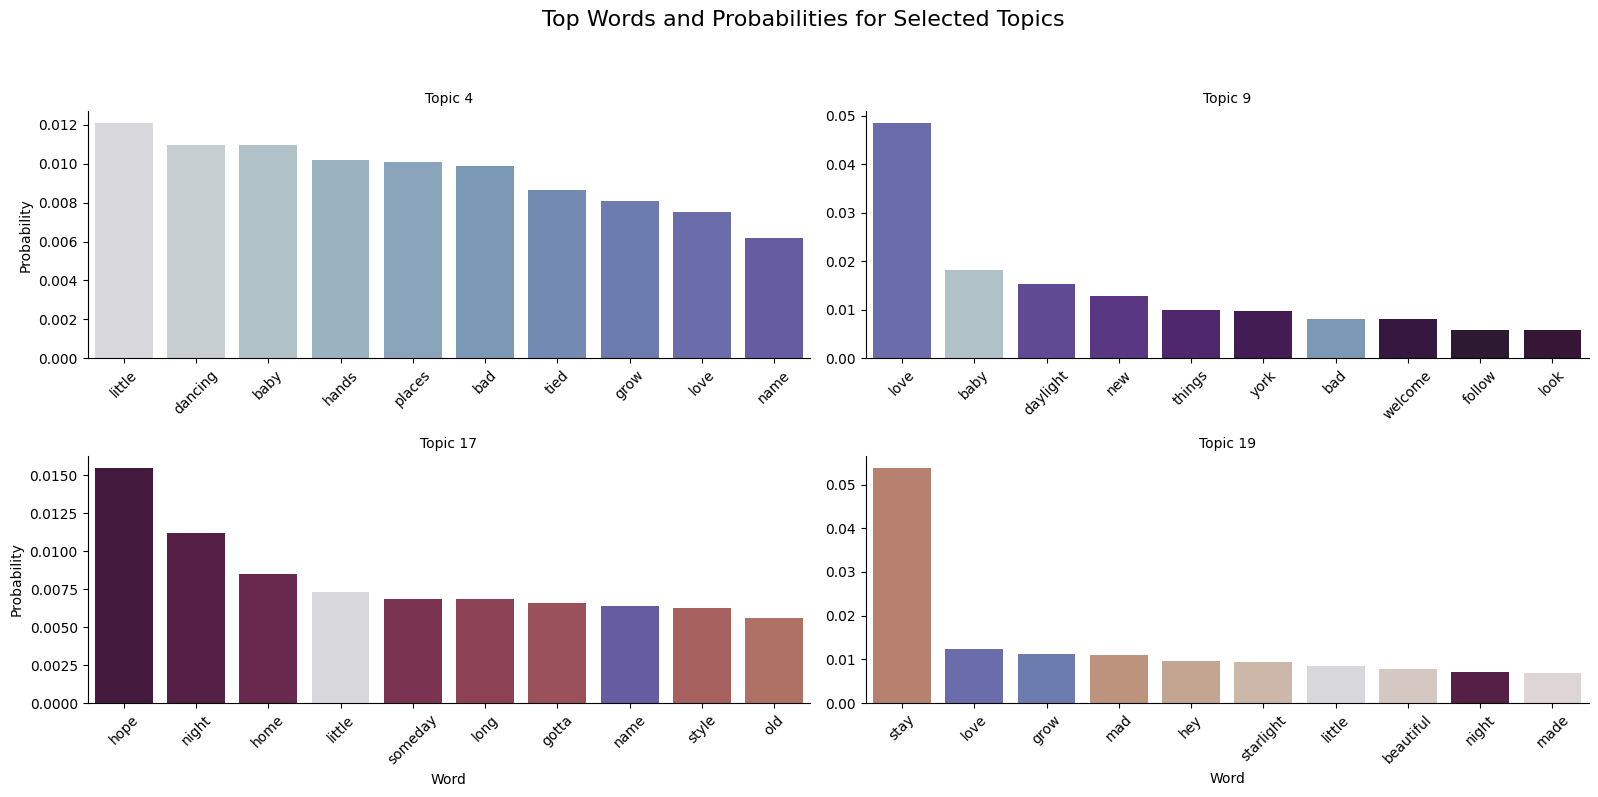

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [43]:
vis = pyLDAvis.gensim_models.prepare(lda_10, corpus, id2word, mds="mmds", R=20)

In [44]:
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6     -0.005977  0.005866       1        1  13.263939
0      0.009983 -0.064792       2        1  12.920901
7     -0.097837 -0.038928       3        1  11.115429
3     -0.039322  0.088938       4        1  11.040568
9      0.098891 -0.079455       5        1  10.327742
1      0.070262 -0.005772       6        1   8.834934
8      0.016934  0.091998       7        1   8.552171
4     -0.049554 -0.089673       8        1   8.476728
5     -0.088713  0.033619       9        1   8.351275
2      0.085332  0.058200      10        1   7.116313, topic_info=         Term       Freq       Total Category  logprob  loglift
331      stay  86.000000   86.000000  Default  20.0000  20.0000
656     shake  61.000000   61.000000  Default  19.0000  19.0000
178      wish  87.000000   87.000000  Default  18.0000  18.0000
1484  trouble  31.000000   31.000000  Default  17.0000  17.0000
1449      red  50.000000   50.000000  Default  16.0000  16.0000
...       ...        ...         ...      ...      ...      ...
114    really   4.736495   29.266776  Topic10  -5.5469   0.8216
154      home   5.931747   65.276143  Topic10  -5.3219   0.2445
101      love   8.277101  215.317526  Topic10  -4.9887  -0.6158
416      well   5.460978   51.898007  Topic10  -5.4046   0.3911
412        us   5.377020   49.634495  Topic10  -5.4201   0.4202

[474 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
1239      1  0.591416  actress
1239      2  0.147854  actress
1239      4  0.147854  actress
1594      4  0.225931   affair
1594      6  0.225931   affair
...     ...       ...      ...
251       6  0.094508    youve
251       7  0.023627    youve
251       8  0.023627    youve
251       9  0.094508    youve
251      10  0.070881    youve

[1645 rows x 3 columns], R=20, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 1, 8, 4, 10, 2, 9, 5, 6, 3])

Sentiment Analysis

### Performing Sentiment Analysis

In [45]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [46]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    return analyzer.polarity_scores(text)

df['sentiment_scores'] = df['Lyrics'].apply(get_sentiment_scores)
df[['Lyrics', 'sentiment_scores']].head()

,Lyrics,sentiment_scores
0,He said the way my blue eyes shinx\nPut those ...,"{'neg': 0.036, 'neu': 0.761, 'pos': 0.204, 'co..."
1,"State the obvious, I didn't get my perfect fan...","{'neg': 0.314, 'neu': 0.619, 'pos': 0.067, 'co..."
2,"Drew looks at me,\nI fake a smile so he won't ...","{'neg': 0.03, 'neu': 0.843, 'pos': 0.126, 'com..."
3,"I don't know what I want, so don't ask me\n'Ca...","{'neg': 0.083, 'neu': 0.798, 'pos': 0.119, 'co..."
4,You have a way of coming easily to me\nAnd whe...,"{'neg': 0.154, 'neu': 0.732, 'pos': 0.114, 'co..."


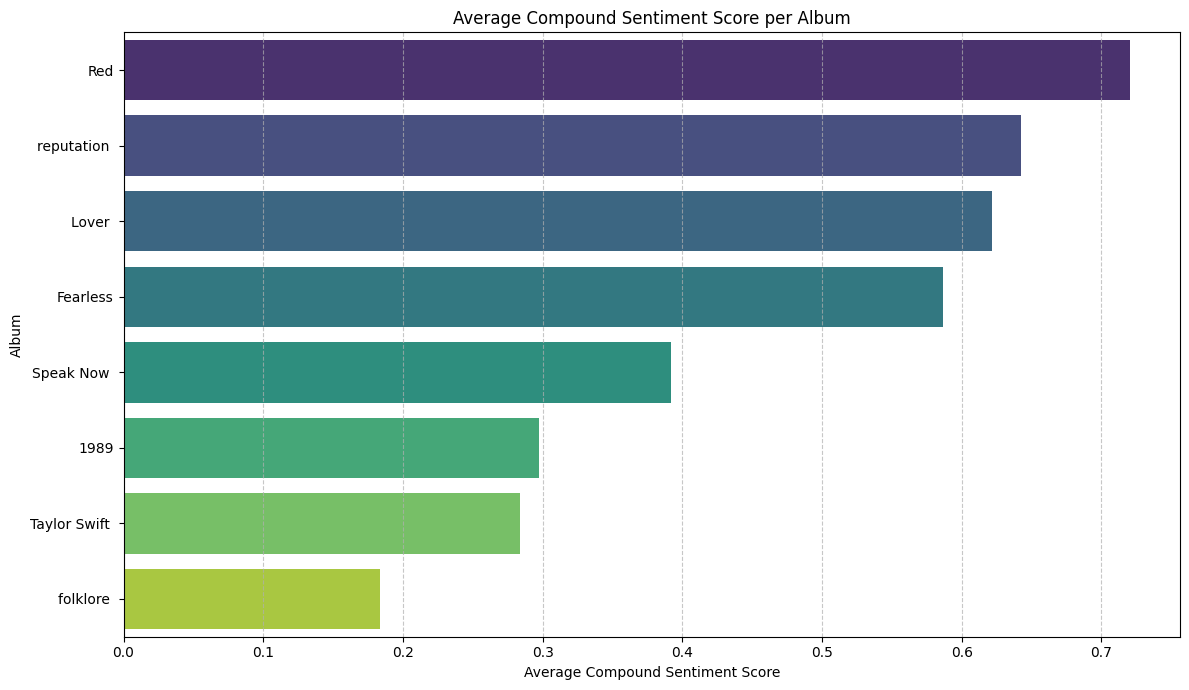

In [48]:
df['compound_sentiment'] = df['sentiment_scores'].apply(lambda x: x['compound'])
album_sentiment = df.groupby('Album')['compound_sentiment'].mean().reset_index()

# Sort albums by average sentiment for better visualization
album_sentiment = album_sentiment.sort_values(by='compound_sentiment', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='compound_sentiment', y='Album', data=album_sentiment, palette='viridis')
plt.title('Average Compound Sentiment Score per Album')
plt.xlabel('Average Compound Sentiment Score')
plt.ylabel('Album')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()